<a href="https://colab.research.google.com/github/Rithika1749/MultiLevelCryptography/blob/main/internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Traffic Sign Recognition.

In [ ]:
import zipfile

with zipfile.ZipFile("/content/archive (1).zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
import os
import cv2

data = []
labels = []

#
path = "/content/dataset/gtsrb/gtsrb"

for label in range(43):
    folder = os.path.join(path, str(label))

    for img in os.listdir(folder):
        image = cv2.imread(os.path.join(folder, img))
        image = cv2.resize(image,(32,32))

        data.append(image)
        labels.append(label)

In [ ]:
data = np.array(data)
labels = np.array(labels)

In [ ]:
data = data / 255.0

cnn model

In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dense(43,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'])

history = model.fit(data, labels, epochs=5)

Epoch 1/5
833/833 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.7027 - loss: 1.0983
Epoch 2/5
833/833 ━━━━━━━━━━━━━━━━━━━━ 34s 41ms/step - accuracy: 0.9539 - loss: 0.1801
Epoch 3/5
833/833 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - accuracy: 0.9765 - loss: 0.0937
Epoch 4/5
833/833 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - accuracy: 0.9835 - loss: 0.0615
Epoch 5/5
833/833 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.9895 - loss: 0.0421


In [ ]:
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'])

history = model.fit(data, labels, epochs=5)

Epoch 1/5
833/833 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.9892 - loss: 0.0397
Epoch 2/5
833/833 ━━━━━━━━━━━━━━━━━━━━ 31s 38ms/step - accuracy: 0.9926 - loss: 0.0259
Epoch 3/5
833/833 ━━━━━━━━━━━━━━━━━━━━ 43s 40ms/step - accuracy: 0.9945 - loss: 0.0201
Epoch 4/5
833/833 ━━━━━━━━━━━━━━━━━━━━ 33s 40ms/step - accuracy: 0.9952 - loss: 0.0184
Epoch 5/5
833/833 ━━━━━━━━━━━━━━━━━━━━ 34s 41ms/step - accuracy: 0.9946 - loss: 0.0187


In [ ]:
model.evaluate(data, labels)

833/833 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9974 - loss: 0.0090


[0.008991377428174019, 0.9974098801612854]

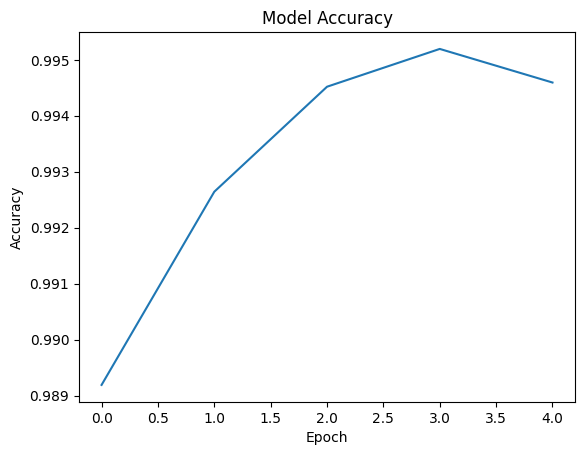

In [ ]:
plt.plot(history.history['accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
classes = {
    0: "Speed limit 20 km/h",
    1: "Speed limit 30 km/h",
    2: "Speed limit 50 km/h",
    3: "Speed limit 60 km/h",
    4: "Speed limit 70 km/h",
    5: "Speed limit 80 km/h",
    6: "End of speed limit 80 km/h",
    7: "Speed limit 100 km/h",
    8: "Speed limit 120 km/h",
    9: "No passing",
    10: "No passing for vehicles over 3.5 tons",
    11: "Right-of-way at the next intersection",
    12: "Priority road",
    13: "Yield",
    14: "Stop",
    15: "No vehicles",
    16: "Vehicles over 3.5 tons prohibited",
    17: "No entry",
    18: "General caution",
    19: "Dangerous curve to the left",
    20: "Dangerous curve to the right",
    21: "Double curve",
    22: "Bumpy road",
    23: "Slippery road",
    24: "Road narrows on the right",
    25: "Road work",
    26: "Traffic signals",
    27: "Pedestrians",
    28: "Children crossing",
    29: "Bicycles crossing",
    30: "Beware of ice/snow",
    31: "Wild animals crossing",
    32: "End of all speed and passing limits",
    33: "Turn right ahead",
    34: "Turn left ahead",
    35: "Ahead only",
    36: "Go straight or right",
    37: "Go straight or left",
    38: "Keep right",
    39: "Keep left",
    40: "Roundabout mandatory",
    41: "End of no passing",
    42: "End of no passing by vehicles over 3.5 tons"
}

In [ ]:
import cv2
import numpy as np

def predict_image(image_path):

    # Read image
    img = cv2.imread(image_path)

    if img is None:
        print("Error: Image not found!")
        return

    # Resize same as training
    img = cv2.resize(img, (32, 32))

    # Normalize
    img = img / 255.0

    # Reshape for model
    img = np.reshape(img, (1, 32, 32, 3))

    # Predict
    prediction = model.predict(img)
    class_index = np.argmax(prediction)

    # Print class number and name
    print("Predicted Class Number:", class_index)
    print("Predicted Sign:", classes[class_index])

    # Optional: confidence
    confidence = np.max(prediction)
    print("Confidence:", confidence)

In [ ]:
predict_image("test_image.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Predicted Class Number: 4
Predicted Sign: Speed limit 70 km/h
Confidence: 0.99943334
